### Pythia-SAE Vizualizations

> End-to-end analysis notebook for a trained Sparse AutoEncoder on pythia-70M layer-4 residual stream activations

#### Imports

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import torch, yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
from torch.utils.data import  DataLoader, TensorDataset
from sklearn.decomposition import PCA

In [3]:
from src.sae import SparseAutoencoder

#### Global Configs

In [4]:
sns.set_theme(style='darkgrid')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(DEVICE)

cuda


#### Local Config, Activations & Model

In [6]:
with open('../configs/pythia.yaml') as f:
    config = yaml.safe_load(f)
    
d_in  = config['activation']['d_in']
d_sae = config['sae']['d_sae']

cache_dir = Path("..") / config['cache']['output_dir']

ckpt_path = (
    Path('..')
    / config['outputs']['run_dir']
    / "sae_final.pt"
) 

print('d_in', d_in)
print('d_sae', d_sae)

d_in 512
d_sae 4096


#### Load Cached Activations

In [7]:
shards = sorted(cache_dir.glob("shard_*.pt"))

activations = torch.cat(
    [
        torch.load(p, map_location="cpu")["activations"]
        for p in shards
    ],
    dim=0
).float()

print("Activations shape:", activations.shape)

Activations shape: torch.Size([16384, 512])


In [8]:
checkpoint = torch.load(ckpt_path, map_location=DEVICE)

model = SparseAutoencoder(
    d_in=d_in,
    d_sae=d_sae
).to(DEVICE)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("Loaded checkpoint step:", checkpoint["step"])

Loaded checkpoint step: 1000


### Run SAE Infernece

In [9]:
loader = DataLoader(
    TensorDataset(activations),
    batch_size = 512,
    shuffle = False
)

all_orig, all_recon, all_features = [], [], []

with torch.no_grad():
    for (batch, ) in loader:
        batch = batch.to(DEVICE)
        recon, feats = model(batch)
        all_orig.append(batch.cpu())
        all_recon.append(recon.cpu())
        all_features.append(feats.cpu())

In [10]:
orig = torch.cat(all_orig)
recon = torch.cat(all_recon)
features = torch.cat(all_features)

print("Original shape:", orig.shape)
print("Reconstruction shape:", recon.shape)
print("Feature shape:", features.shape)

Original shape: torch.Size([16384, 512])
Reconstruction shape: torch.Size([16384, 512])
Feature shape: torch.Size([16384, 4096])


#### Compute Reconstruction Error

In [11]:
mse_per_token = ((orig - recon) ** 2).mean(dim=-1).numpy()

var_per_token = (
    (
        orig - orig.mean(dim=-1, keepdim=True)
    ) ** 2
).mean(dim=-1).numpy()

mean_mse = mse_per_token.mean()

var_explained = 1.0 - (
    mean_mse / var_per_token.mean()
)

print(f"Mean MSE: {mean_mse:.6f}")
print(f"Variance Explained: {var_explained:.4f}")

Mean MSE: 0.000567
Variance Explained: 0.9991


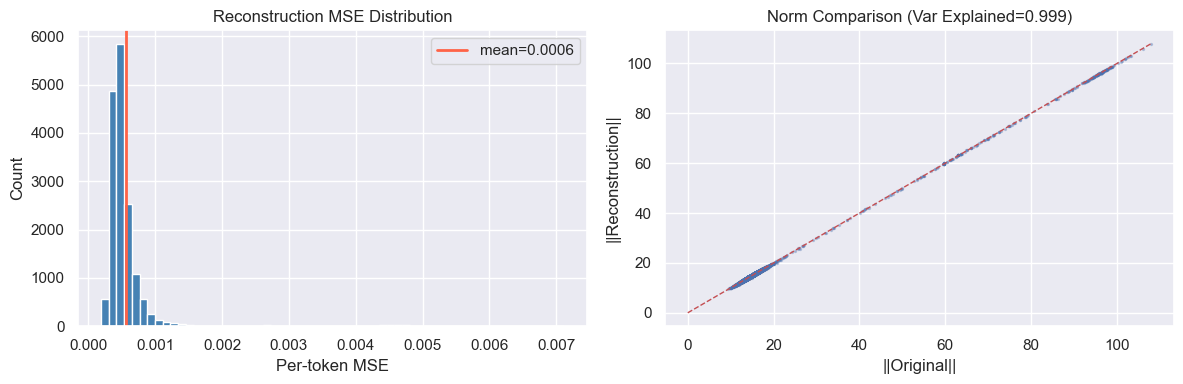

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of MSE

axes[0].hist(
    mse_per_token,
    bins=60,
    color="steelblue"
)

axes[0].axvline(
    mean_mse,
    color="tomato",
    linewidth=2,
    label=f"mean={mean_mse:.4f}"
)

axes[0].set_title("Reconstruction MSE Distribution")
axes[0].set_xlabel("Per-token MSE")
axes[0].set_ylabel("Count")
axes[0].legend()

# Norm Comparison

orig_norm = orig.norm(dim=-1).numpy()
recon_norm = recon.norm(dim=-1).numpy()

axes[1].scatter(
    orig_norm,
    recon_norm,
    s=2,
    alpha=0.3
)

lim = max(orig_norm.max(), recon_norm.max())

axes[1].plot(
    [0, lim],
    [0, lim],
    "r--",
    linewidth=1
)

axes[1].set_title(
    f"Norm Comparison (Var Explained={var_explained:.3f})"
)

axes[1].set_xlabel("||Original||")
axes[1].set_ylabel("||Reconstruction||")

plt.tight_layout()
plt.show()

### Sparsity Analysis

In [15]:
l0_per_token = (
    (features > 0)
    .float()
    .sum(dim=-1)
    .numpy()
)

In [16]:
feature_active = (
    (features > 0)
    .any(dim=0)
    .numpy()
)

dead_frac = 1.0 - feature_active.mean()

print(f"Mean L0: {l0_per_token.mean():.2f}")
print(f"Dead Features: {dead_frac:.2%}")

Mean L0: 3827.48
Dead Features: 0.00%


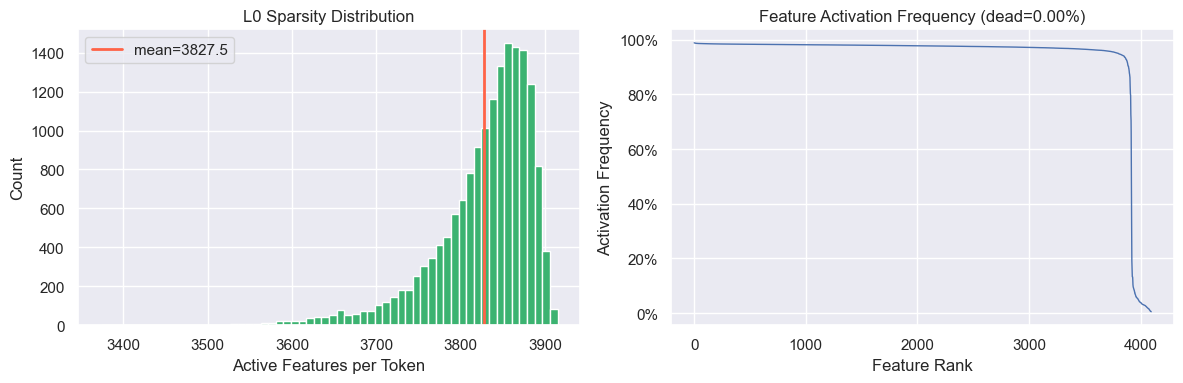

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# L0 Histogram

axes[0].hist(
    l0_per_token,
    bins=60,
    color="mediumseagreen"
)

axes[0].axvline(
    l0_per_token.mean(),
    color="tomato",
    linewidth=2,
    label=f"mean={l0_per_token.mean():.1f}"
)

axes[0].set_title("L0 Sparsity Distribution")
axes[0].set_xlabel("Active Features per Token")
axes[0].set_ylabel("Count")
axes[0].legend()

# Activation Frequency
freq = (
    (features > 0)
    .float()
    .mean(dim=0)
    .numpy()
)

axes[1].plot(
    np.sort(freq)[::-1],
    linewidth=1
)

axes[1].set_title(
    f"Feature Activation Frequency (dead={dead_frac:.2%})"
)

axes[1].set_xlabel("Feature Rank")
axes[1].set_ylabel("Activation Frequency")

axes[1].yaxis.set_major_formatter(
    ticker.PercentFormatter(xmax=1)
)

plt.tight_layout()
plt.show()

### Top-K feature Heatmap

In [18]:
N_TOKENS   = 200
N_FEATURES = 50

In [19]:
# Most active features

freq = (features > 0).float().mean(dim = 0)

top_feature_idx = (
    freq.topk(N_FEATURES).indices
    .numpy()
)


In [20]:
rng = np.random.default_rng(42)

token_idx = np.sort(
    rng.choice(
        len(features),
        size=N_TOKENS,
        replace=False
    )
)

heatmap_data = (
    features[token_idx][:, top_feature_idx]
    .numpy()
)

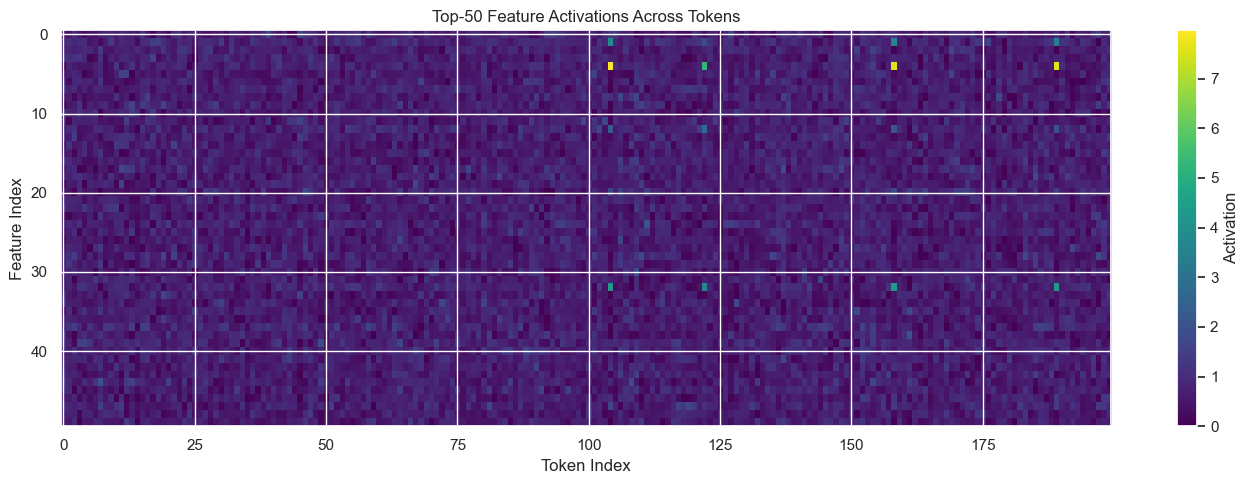

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))

im = ax.imshow(
    heatmap_data.T,
    aspect="auto",
    cmap="viridis",
    interpolation="nearest"
)

plt.colorbar(im, ax=ax, label="Activation")

ax.set_title(
    "Top-50 Feature Activations Across Tokens"
)

ax.set_xlabel("Token Index")
ax.set_ylabel("Feature Index")

plt.tight_layout()
plt.show()

### PCA Visualization

In [22]:
N_PCA = 2000

rng = np.random.default_rng(0)

idx = rng.choice(
    len(orig),
    size=N_PCA,
    replace=False
)

orig_np = orig[idx].numpy()
recon_np = recon[idx].numpy()

In [23]:
pca = PCA(n_components=2)

orig_2d = pca.fit_transform(orig_np)
recon_2d = pca.transform(recon_np)

var_ratio = pca.explained_variance_ratio_

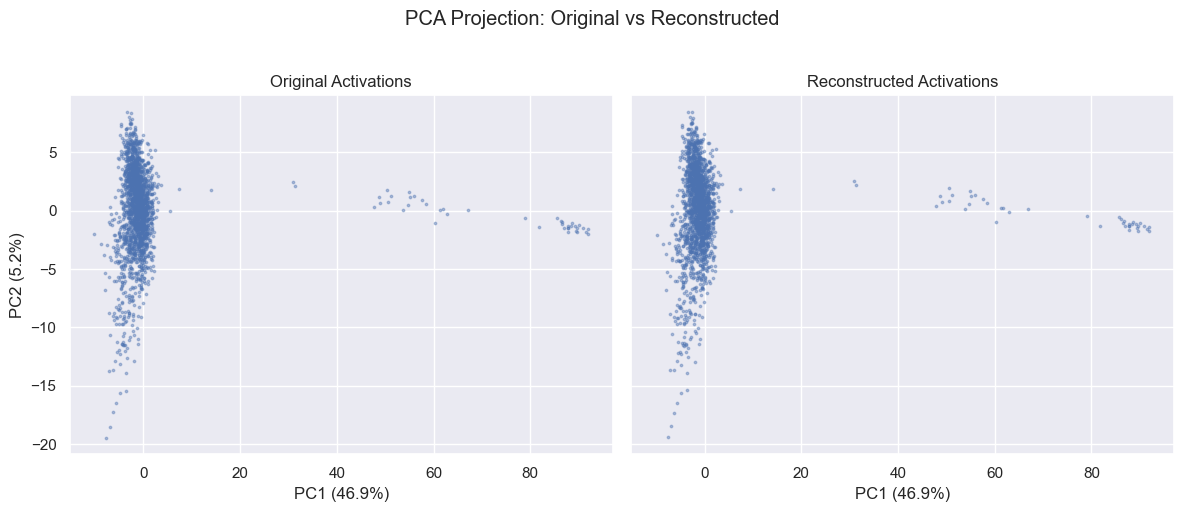

In [24]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    sharex=True,
    sharey=True
)

# Original

axes[0].scatter(
    orig_2d[:, 0],
    orig_2d[:, 1],
    s=3,
    alpha=0.4
)

axes[0].set_title("Original Activations")

axes[0].set_xlabel(
    f"PC1 ({var_ratio[0]:.1%})"
)

axes[0].set_ylabel(
    f"PC2 ({var_ratio[1]:.1%})"
)

# Reconstruction

axes[1].scatter(
    recon_2d[:, 0],
    recon_2d[:, 1],
    s=3,
    alpha=0.4,
)

axes[1].set_title("Reconstructed Activations")

axes[1].set_xlabel(
    f"PC1 ({var_ratio[0]:.1%})"
)

plt.suptitle(
    "PCA Projection: Original vs Reconstructed",
    y=1.02
)

plt.tight_layout()
plt.show()